🔒 Random seed telah dikunci di angka 42. Hasil eksekusi akan selalu sama!

[STEP 1] Loading Pre-trained IndoNLGTokenizer...
----------------------------------------
Subjek        : SUB4
Kalimat Target: hasilnya sedikit mengejutkan
Shape Matriks : (555, 14) (Time x Channels)

Mengekstraksi fitur Hilbert Spectrum (Stabil karena ada seed lock di dalam loop)...
Memuat model dari SUB4_eq_3_0_hilbert_best_model_10_1_IndoGPT.pt...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: indobenchmark/indogpt
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
lm_head.weight                          | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model berhasil dimuat!

Memulai proses decoding IndoGPT (Beam Search k=3)...
--------------------------------------------------
[Frame 017/18] Prediksi: hasilnya sedikit mengejutkan                      
--------------------------------------------------
Hasil Akhir  : 'hasilnya sedikit mengejutkan'
Ground Truth : 'hasilnya sedikit mengejutkan'

Mengintip 3 Semesta Teratas secara Autoregressive:
Step 01 (T=000) | S-1: '<blank>' (-1.1)  |  S-2: 'hasilnya' (-2.0)  |  S-3: 'dia' (-2.6)  |  
Step 02 (T=001) | S-1: 'hasilnya' (-2.1)  |  S-2: 'dia' (-3.1)  |  S-3: 'hasilnya' (-4.1)  |  
Step 03 (T=002) | S-1: 'hasilnya' (-3.3)  |  S-2: 'hasilnya sedikit' (-3.3)  |  S-3: 'hasilnya sedikit mengejutkan' (-3.8)  |  
Step 04 (T=003) | S-1: 'hasilnya sedikit mengejutkan' (-3.8)  |  S-2: 'hasilnya sedikit mengejutkan' (-3.9)  |  S-3: 'hasilnya sedikit' (-4.2)  |  
Step 05 (T=004) | S-1: 'hasilnya sedikit mengejutkan' (-3.8)  |  S-2: 'hasilnya sedikit mengejutkan' (-3.9)  |  S-3: 'hasilnya sedikit

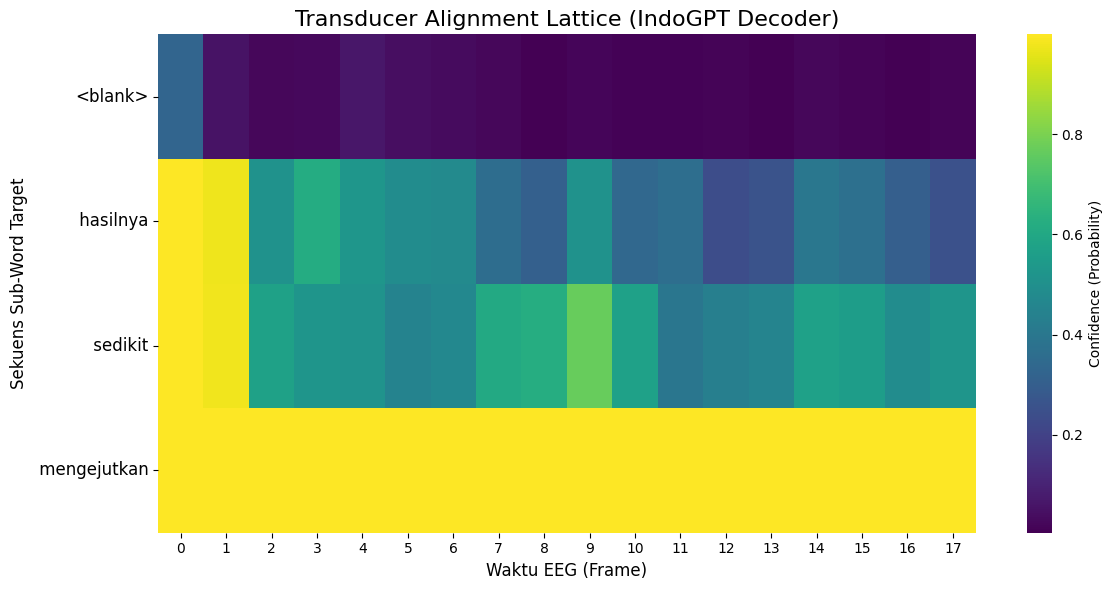

In [2]:
import os
import sys
import time
import random
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

from PyEMD import CEEMDAN
from scipy.signal import hilbert
from sklearn.decomposition import FastICA
from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. BYPASS HUGGINGFACE UNTUK INDOBENCHMARK
# ==============================================================================
import transformers.utils
import transformers.utils.generic

if not hasattr(transformers.utils, 'is_tf_available'):
    transformers.utils.is_tf_available = lambda: False
if not hasattr(transformers.utils.generic, '_is_jax'):
    transformers.utils.generic._is_jax = lambda x: False
if not hasattr(transformers.utils.generic, '_is_tensorflow'):
    transformers.utils.generic._is_tensorflow = lambda x: False
if not hasattr(transformers.utils.generic, '_is_numpy'):
    transformers.utils.generic._is_numpy = lambda x: isinstance(x, np.ndarray)
if not hasattr(transformers.utils.generic, '_is_torch'):
    transformers.utils.generic._is_torch = lambda x: torch.is_tensor(x)
if not hasattr(transformers.utils.generic, '_is_torch_device'):
    transformers.utils.generic._is_torch_device = lambda x: isinstance(x, torch.device)

from indobenchmark import IndoNLGTokenizer

# ==============================================================================
# 1. PENGUNCIAN SEED GLOBAL (REPRODUCIBILITY)
# ==============================================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"🔒 Random seed telah dikunci di angka {seed}. Hasil eksekusi akan selalu sama!")

seed_everything(42)

# ==============================================================================
# 2. KONFIGURASI PATH & PARAMETER EKSRAKSI
# ==============================================================================
SUBJECT = 'SUB4'
PROJECT_ROOT = os.path.abspath('../../../') 
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, 'dataset/raw')
TRAIN_CSV = os.path.join(PROJECT_ROOT, f'dataset/{SUBJECT}_eq_3_0_train.csv')

model_path = os.path.join(PROJECT_ROOT, 'src')
if model_path not in sys.path:
    sys.path.insert(0, model_path)

EEG_CHANNELS = ['EEG.AF3', 'EEG.F7', 'EEG.F3', 'EEG.FC5', 'EEG.T7', 
                'EEG.P7', 'EEG.O1', 'EEG.O2', 'EEG.P8', 'EEG.T8', 
                'EEG.FC6', 'EEG.F4', 'EEG.F8', 'EEG.AF4']

CONFIG = {
    'sample_rate': 256, 'hop_length': 8, 'win_length': 16,
    'f_min': 0.2, 'f_max': 45.0, 'ica_threshold': 0.8,
    'start_imf': 2, 'ceemdan_trials': 15, 'n_freq_bins': 65,
}

# ==============================================================================
# 3. PERSIAPAN DATA EEG, TOKENIZER INDOGPT, & TARGET SHIFTING
# ==============================================================================
print("\n[STEP 1] Loading Pre-trained IndoNLGTokenizer...")
tokenizer = IndoNLGTokenizer.from_pretrained("indobenchmark/indogpt")
def dummy_pad(encoded_inputs, **kwargs): return encoded_inputs
tokenizer.pad = dummy_pad

df_train = pd.read_csv(TRAIN_CSV)
sample_row = df_train.iloc[0]

id_val = str(sample_row['id'])
subject = sample_row['subject']
gender = sample_row['gender']
ground_truth_sentence = sample_row['sentence']

csv_folder = os.path.join(RAW_DATA_PATH, gender, subject, 'csv')
matching_files = [f for f in os.listdir(csv_folder) if f.startswith(id_val + '_') and f.endswith('.bp.csv')]
file_path = os.path.join(csv_folder, matching_files[0])

df_eeg = pd.read_csv(file_path, skiprows=1)
raw_eeg_signal = df_eeg[EEG_CHANNELS].values

print("-" * 40)
print(f"Subjek        : {subject}")
print(f"Kalimat Target: {ground_truth_sentence}")
print(f"Shape Matriks : {raw_eeg_signal.shape} (Time x Channels)")

# SHIFTING: Target digeser +1 seperti di DataLoader
encoded_tokens = tokenizer.encode(ground_truth_sentence)
shifted_tokens = [t + 1 for t in encoded_tokens]
tensor_target = torch.LongTensor(shifted_tokens)

# ==============================================================================
# 4. PEMURNIAN ARTIFAK & EKSTRAKSI FITUR (DENGAN CEEMDAN SEED LOCK)
# ==============================================================================
def remove_ocular_artifacts_ica_demo(eeg_signal, ch_names, threshold=0.6):
    frontal_indices = [i for i, ch in enumerate(ch_names) if 'AF3' in ch or 'AF4' in ch]
    ica = FastICA(n_components=eeg_signal.shape[1], random_state=42, max_iter=1000, tol=0.01)
    components = ica.fit_transform(eeg_signal) 
    
    bad_components = []
    for i in range(components.shape[1]):
        is_artifact = False
        for f_idx in frontal_indices:
            corr, _ = pearsonr(components[:, i], eeg_signal[:, f_idx])
            if abs(corr) > threshold:
                is_artifact = True
                break
        if is_artifact: bad_components.append(i)

    components_cleaned = components.copy()
    if bad_components:
        components_cleaned[:, bad_components] = 0.0
        
    return ica.inverse_transform(components_cleaned), bad_components

cleaned_eeg_signal, bad_comps = remove_ocular_artifacts_ica_demo(raw_eeg_signal, EEG_CHANNELS, CONFIG['ica_threshold'])

def compute_hilbert_spectrum_full(eeg_signal, config):
    n_samples, n_channels = eeg_signal.shape
    fs, f_min, f_max, n_bins = config['sample_rate'], config['f_min'], config['f_max'], config['n_freq_bins']
    hop_length, win_length = config['hop_length'], config['win_length']
    start_imf = config.get('start_imf', 2)
    freq_edges = np.linspace(f_min, f_max, n_bins + 1)
    
    # CEEMDAN dengan noise 0.2 seperti saat pelatihan
    ceemdan = CEEMDAN(trials=config['ceemdan_trials'], noise_scale=0.2, parallel=False)
    all_channel_spectra = []
    
    for ch_idx in range(n_channels):
        # KUNCI MUTLAK: np.random.seed di dalam loop untuk konsistensi noise
        np.random.seed(42 + ch_idx)
        
        signal = eeg_signal[:, ch_idx].astype(np.float64)
        imfs = ceemdan(signal)
        imfs = imfs[start_imf:] if start_imf < imfs.shape[0] else imfs[-1:]
        
        hilbert_spec = np.zeros((n_bins, n_samples))
        for i in range(imfs.shape[0]):
            analytic_signal = hilbert(imfs[i])
            amp, phase = np.abs(analytic_signal), np.unwrap(np.angle(analytic_signal))
            freq = (np.diff(phase) / (2.0*np.pi) * fs)
            freq = np.insert(freq, 0, freq[0])
            bin_indices = np.digitize(freq, freq_edges) - 1
            for t in range(n_samples):
                b = bin_indices[t]
                if 0 <= b < n_bins: hilbert_spec[b, t] += (amp[t] ** 2) 
        
        current_n_samples = n_samples
        if current_n_samples > win_length:
            remainder = (current_n_samples - win_length) % hop_length
            if remainder > 0:
                pad_length = hop_length - remainder
                hilbert_spec = np.pad(hilbert_spec, ((0, 0), (0, pad_length)), mode='constant')
                current_n_samples += pad_length

        if current_n_samples < win_length:
            framed_spec = np.zeros((n_bins, 0)) 
        else:
            n_frames = 1 + (current_n_samples - win_length) // hop_length
            framed_spec = np.zeros((n_bins, n_frames))
            for t_idx in range(n_frames):
                start = t_idx * hop_length
                end = start + win_length  
                framed_spec[:, t_idx] = np.mean(hilbert_spec[:, start:end], axis=1)  
        all_channel_spectra.append(framed_spec)
        
    all_channel_spectra = np.array(all_channel_spectra)
    features_transposed = all_channel_spectra.transpose(2, 0, 1)
    features_flat = features_transposed.reshape(features_transposed.shape[0], -1)
    features_flat = np.log(features_flat + 1e-9)
    mean_val, std_val = np.mean(features_flat, axis=0), np.std(features_flat, axis=0)
    features_flat = (features_flat - mean_val) / (std_val + 1e-6)
    
    return features_flat.astype(np.float32)

print("\nMengekstraksi fitur Hilbert Spectrum (Stabil karena ada seed lock di dalam loop)...")
final_features = compute_hilbert_spectrum_full(cleaned_eeg_signal, CONFIG)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
features = torch.FloatTensor(final_features).unsqueeze(0).to(DEVICE)
feature_length = torch.LongTensor([final_features.shape[0]]).to(DEVICE)
targets = tensor_target.unsqueeze(0).to(DEVICE)

# ==============================================================================
# 5. PERSIAPAN & PEMUATAN MODEL INDOGPT TRANSDUCER
# ==============================================================================
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'src/pipelines/training')
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, f'{SUBJECT}_eq_3_0_hilbert_best_model_10_1_IndoGPT.pt')

# Konfigurasi Model Baru
CONFIG['input_dim'] = 14 * 65
CONFIG['encoder_dim'] = 356
CONFIG['decoder_dim'] = 768
CONFIG['joint_dim'] = 768
CONFIG['vocab_size'] = tokenizer.vocab_size + 1 # +1 untuk blank
CONFIG['num_layers'] = 4
CONFIG['encoder_dropout'] = 0.2
CONFIG['decoder_dropout'] = 0.2

from model.model import ConformerIndoGPTTransducer

print(f"Memuat model dari {os.path.basename(BEST_MODEL_PATH)}...")
model = ConformerIndoGPTTransducer(CONFIG).to(DEVICE)

try:
    saved_data = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(saved_data['model_state_dict'], strict=False)
    model.eval()
    print("✅ Model berhasil dimuat!")
except FileNotFoundError:
    print(f"❌ ERROR: File model tidak ditemukan di {BEST_MODEL_PATH}")

# ==============================================================================
# 6. DEMONSTRASI & VISUALISASI DENGAN BEAM DECODER INDOGPT
# ==============================================================================

def live_beam_decode_demo(model, features, tokenizer, beam_size=3, max_sym_per_frame=3, delay=0.1):
    """Mendemonstrasikan inferensi selaras dengan BeamDecoder IndoGPT baru (A/B Sets)"""
    with torch.no_grad():
        device = features.device
        encoder_out = model.encoder(features)
        
        blank_id = 0
        T = encoder_out.size(1)
        
        # B = [(list_token_ids, cumulative_score)]
        B = [([blank_id], 0.0)]
        
        print(f"\nMemulai proses decoding IndoGPT (Beam Search k={beam_size})...")
        print("-" * 50)
        
        for t in range(T):
            f_t = encoder_out[:, t:t+1, :]
            
            A = B 
            B = []
            
            for sym_count in range(max_sym_per_frame):
                new_A = []
                for token_ids, score in A:
                    y = torch.tensor([token_ids], device=device)
                    g_u, _ = model.decoder(y)
                    g_u_last = g_u[:, -1:, :] 

                    logits = model.joiner(f_t, g_u_last)
                    log_probs = F.log_softmax(logits, dim=-1).view(-1)
                    
                    # Top-K expansion
                    top_log_probs, top_ids = torch.topk(log_probs, beam_size)
                    
                    for i in range(len(top_ids)):
                        v = top_ids[i].item()
                        p = top_log_probs[i].item()
                        
                        if v == blank_id:
                            # Jika Blank: Pindah ke B (Lanjut ke t+1)
                            B.append((token_ids, score + p))
                        else:
                            # Jika Sub-Word: Tetap di A
                            new_A.append((token_ids + [v], score + p))
                            
                # Hentikan loop frame jika semua prediksi blank
                if not new_A:
                    break
                    
                # Pruning untuk list A
                A = sorted(new_A, key=lambda x: x[1], reverse=True)[:beam_size]
            
            # Pindahkan sisa yang belum blank di A agar tidak hangus, masuk ke t+1
            B.extend(A)
            B = sorted(B, key=lambda x: x[1], reverse=True)[:beam_size]
            
            # Ekstrak ID terbaik dan Hapus Shifting (-1) untuk IndoNLGTokenizer
            best_ids = B[0][0]
            clean_ids = [i - 1 for i in best_ids if i > 0]
            current_best_sentence = tokenizer.decode(clean_ids).strip()
            
            print(f"\r[Frame {t:03d}/{T}] Prediksi: {current_best_sentence.ljust(50)}", end="")
            time.sleep(delay)
            
        print("\n" + "-" * 50)
        best_ids = B[0][0]
        clean_ids = [i - 1 for i in best_ids if i > 0]
        final_text = tokenizer.decode(clean_ids).strip()
        print(f"Hasil Akhir  : '{final_text}'")
        print(f"Ground Truth : '{ground_truth_sentence}'\n")

def inspect_beam_candidates(model, features, tokenizer, beam_size=3, inspect_steps=10, max_sym_per_frame=3):
    """Melihat semesta kandidat teratas dengan logika IndoGPT (A/B Sets)"""
    with torch.no_grad():
        device = features.device
        encoder_out = model.encoder(features)
        
        blank_id = 0
        T = encoder_out.size(1)
        B = [([blank_id], 0.0)]
        
        print(f"Mengintip {beam_size} Semesta Teratas secara Autoregressive:")
        print("="*80)
        
        t = 0
        step = 1
        
        while t < T and step <= inspect_steps:
            f_t = encoder_out[:, t:t+1, :]
            
            A = B 
            B = []
            
            for sym_count in range(max_sym_per_frame):
                new_A = []
                for token_ids, score in A:
                    y = torch.tensor([token_ids], device=device)
                    g_u, _ = model.decoder(y)
                    g_u_last = g_u[:, -1:, :] 

                    logits = model.joiner(f_t, g_u_last)
                    log_probs = F.log_softmax(logits, dim=-1).view(-1)
                    top_log_probs, top_ids = torch.topk(log_probs, beam_size)
                    
                    for i in range(len(top_ids)):
                        v = top_ids[i].item()
                        p = top_log_probs[i].item()
                        
                        if v == blank_id:
                            B.append((token_ids, score + p))
                        else:
                            new_A.append((token_ids + [v], score + p))
                            
                if not new_A:
                    break
                    
                A = sorted(new_A, key=lambda x: x[1], reverse=True)[:beam_size]
            
            B.extend(A)
            B = sorted(B, key=lambda x: x[1], reverse=True)[:beam_size]
            
            print(f"Step {step:02d} (T={t:03d}) |", end=" ")
            for i in range(min(beam_size, len(B))):
                score = B[i][1]
                clean_ids = [token - 1 for token in B[i][0] if token > 0]
                teks = tokenizer.decode(clean_ids).strip() if clean_ids else "<blank>"
                print(f"S-{i+1}: '{teks}' ({score:.1f})", end="  |  ")
            print("")
            
            step += 1
            t += 1

def plot_joiner_training_alignment(model, features, targets, tokenizer):
    """Plotting lattice alignment (Memperhatikan Shifting Sub-Word IndoGPT)"""
    with torch.no_grad():
        encoder_out = model.encoder(features)
        
        batch_size = targets.shape[0]
        blank_col = torch.zeros((batch_size, 1), dtype=torch.long, device=DEVICE)
        decoder_input = torch.cat([blank_col, targets], dim=1)
        hidden_state = None # IndoGPT tidak membutuhkan init_hidden
        
        # Panggil forward pass langsung ke decoder
        decoder_out, _ = model.decoder(decoder_input)
        
        enc_proj = model.joiner.encoder_proj(encoder_out)
        dec_proj = model.joiner.decoder_proj(decoder_out)
        joint = enc_proj.unsqueeze(2) + dec_proj.unsqueeze(1)
        joint = model.joiner.activation(joint)
        logits = model.joiner.output_proj(joint)
        
        probs = torch.nn.functional.softmax(logits, dim=-1)
        max_probs = probs.max(dim=-1).values[0].cpu().numpy()
        
        plt.figure(figsize=(12, 6))
        sns.heatmap(max_probs.T, cmap='viridis', cbar_kws={'label': 'Confidence (Probability)'})
        
        # Un-shift target untuk label Sumbu Y
        target_chars = ['<blank>'] + [tokenizer.decode([i.item() - 1]) for i in targets[0]]
        plt.yticks(ticks=np.arange(len(target_chars)) + 0.5, labels=target_chars, rotation=0, fontsize=12)
        
        plt.title("Transducer Alignment Lattice (IndoGPT Decoder)", fontsize=16)
        plt.xlabel("Waktu EEG (Frame)", fontsize=12)
        plt.ylabel("Sekuens Sub-Word Target", fontsize=12)
        
        plt.tight_layout()
        plt.show()

# ==============================================================================
# EKSEKUSI FUNGSI DEMONSTRASI
# ==============================================================================
# 1. Jalankan animasi Beam Search
live_beam_decode_demo(model, features, tokenizer, beam_size=3, max_sym_per_frame=3, delay=0.05)

# 2. Intip persaingan hipotesis teratas
inspect_beam_candidates(model, features, tokenizer, beam_size=3, inspect_steps=15, max_sym_per_frame=3)

# 3. Buat plot Heatmap
plot_joiner_training_alignment(model, features, targets, tokenizer)